**Source notebook:** [`06_simses_bess_degradation_demo.ipynb`](../../notebooks/06_simses_bess_degradation_demo.ipynb)


# 06 — SimSES BESS Degradation Demonstration for WEC Smoothing Profiles

This optional final notebook connects selected storage-aware smoothing profiles from [Notebook 05](../outputs/pdf/05_storage_smoothing_metrics.pdf) to a simple stationary battery simulation workflow using [SimSES](https://tum-ees.github.io/simses/).

The goal is not to optimize BESS sizing, validate a battery lifetime model, or produce a bankable degradation study. Instead, the notebook asks:

> Given selected WEC smoothing duty cycles from Notebook 05, how can they be prepared for battery simulation, and what operation and degradation-relevant indicators can be inspected?

The analysis remains a demonstration. The WEC power signal is still the simplified 250 kW proxy developed earlier in the project, and the selected storage profiles remain smoothing-implied duty cycles rather than optimized BESS dispatch schedules. SimSES is used here as a practical battery-simulation tool to illustrate a possible next step in the workflow, not as final validation of battery lifetime or project design.


## 1. Scope, selected profiles, and simulation concept

This notebook builds on the previous workflow steps:

* [Literature map and research context](../outputs/pdf/00_literature_map.pdf)
* [Wave-resource data preparation](../outputs/pdf/01_wave_data_preparation.pdf)
* [Estimated WEC power from sea-state conditions](../outputs/pdf/02_wec_power_estimation.pdf)
* [Short-term point forecasting baselines](../outputs/pdf/03_forecasting_baselines.pdf)
* [Prediction intervals and uncertainty estimation](../outputs/pdf/04_prediction_intervals_uncertainty.pdf)
* [Storage-aware smoothing metrics](../outputs/pdf/05_storage_smoothing_metrics.pdf)
* SimSES BESS degradation demonstration

The previous notebooks prepared open wave-resource observations, estimated WEC power using a simplified generic power-matrix approach, evaluated short-term point forecasts, calibrated empirical prediction intervals, and converted selected grid-export smoothing rules into storage power, energy, throughput, and equivalent-cycle metrics.

This notebook takes one further optional step. It replays selected storage power profiles through a simple SimSES battery model to inspect battery operation and degradation-relevant outputs under WEC smoothing duty cycles.

The selected cases are limited to the 30 min forecast horizon and 2 h smoothing window:

* observed-power smoothing;
* forecast-informed smoothing.

For consistency with the previous forecasting workflow, the forecast-informed smoothing profile replayed here comes from the Ridge point forecast developed in [Notebook 03](../outputs/pdf/03_forecasting_baselines.pdf). The uncertainty-aware lower-bound smoothing profile from [Notebook 05](../outputs/pdf/05_storage_smoothing_metrics.pdf) was based on the 90% conformal-style prediction intervals developed in [Notebook 04](../outputs/pdf/04_prediction_intervals_uncertainty.pdf), but that additional case is not replayed here so that the battery-simulation demonstration remains compact.

The storage power convention follows Notebook 05:

$p_{st} = p_{wec} - p_{grid}$

where:

* $p_{wec}$ is the estimated WEC power;
* $p_{grid}$ is the selected smoothed grid-export target;
* $p_{st}$ is the storage balancing power.

The sign convention is:

* $p_{st} > 0$: storage charges or absorbs surplus relative to the grid-export target;
* $p_{st} < 0$: storage discharges or supports the grid-export target.

The battery replay is organized in two levels. First, one continuous representative segment is used for detailed time-series inspection. This gives an intuitive view of the storage duty cycle, including charge/discharge switching, state-of-charge movement, cumulative throughput, equivalent cycling, and available SimSES state-of-health outputs.

After the detailed segment replay, the selected fold and segment profiles are replayed independently to summarize operation and stress-related indicators across the evaluation data. Because the rolling-origin folds overlap in calendar time and the continuous segments have different durations, these summaries are not treated as one physical lifetime trajectory. Instead, they are reported using descriptive and duration-normalized indicators such as SOC range, throughput per day, equivalent full cycles per day, C-rate proxies, and available degradation-relevant outputs.

The results should therefore be interpreted as reproducible workflow and screening indicators only. They remain conditional on the simplified WEC power estimate, the smoothing rules, the simple BESS sizing assumptions used here, and the specific SimSES battery model configuration.


In [1]:
import sys
from pathlib import Path

SRC_DIR = Path("../src")

if str(SRC_DIR) not in sys.path:
    sys.path.append(str(SRC_DIR))

from bess_replay import (
    plot_replay_distribution_grid,
    compute_energy_balanced_start_soc,
    replay_simses_profile,
    simulate_lumped_temperature_response,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True


# Paths are relative to the notebooks/ directory.
NOTEBOOK_ID = "notebook_06"

OUTPUTS_DIR = Path("../outputs")

TABLES_DIR = OUTPUTS_DIR / "tables" / NOTEBOOK_ID
FIGURES_DIR = OUTPUTS_DIR / "figures" / NOTEBOOK_ID
NOTEBOOK_OUTPUT_DIR = OUTPUTS_DIR / NOTEBOOK_ID

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
NOTEBOOK_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


STORAGE_TIMESERIES_PATH = (
    OUTPUTS_DIR
    / "notebook_05"
    / "storage_smoothing_timeseries.parquet"
)

STORAGE_METRICS_SUMMARY_PATH = (
    OUTPUTS_DIR
    / "tables"
    / "notebook_05"
    / "storage_smoothing_metrics_summary.csv"
)

STORAGE_METRICS_BY_FOLD_PATH = (
    OUTPUTS_DIR
    / "tables"
    / "notebook_05"
    / "storage_smoothing_metrics_by_fold.csv"
)

## 2. Inputs from the storage-smoothing notebook

This section loads the storage-smoothing time series and summary tables generated by [Notebook 05](../outputs/pdf/05_storage_smoothing_metrics.pdf). These files contain the smoothed grid-export targets, implied storage balancing power, fold-level metrics, and overall smoothing summaries used for the battery replay demonstration.

In [2]:
storage_timeseries = pd.read_parquet(STORAGE_TIMESERIES_PATH)
storage_metrics_summary = pd.read_csv(STORAGE_METRICS_SUMMARY_PATH)
storage_metrics_by_fold = pd.read_csv(STORAGE_METRICS_BY_FOLD_PATH)

storage_timeseries["target_time"] = pd.to_datetime(storage_timeseries["target_time"])

input_summary = pd.DataFrame(
    [
        ["Storage smoothing time series", STORAGE_TIMESERIES_PATH, len(storage_timeseries)],
        ["Storage metrics summary", STORAGE_METRICS_SUMMARY_PATH, len(storage_metrics_summary)],
        ["Storage metrics by fold", STORAGE_METRICS_BY_FOLD_PATH, len(storage_metrics_by_fold)],
    ],
    columns=["Input", "Path", "Rows"],
)

display(Markdown(input_summary.to_markdown(index=False)))

| Input                         | Path                                                                |   Rows |
|:------------------------------|:--------------------------------------------------------------------|-------:|
| Storage smoothing time series | ../outputs/notebook_05/storage_smoothing_timeseries.parquet         | 166582 |
| Storage metrics summary       | ../outputs/tables/notebook_05/storage_smoothing_metrics_summary.csv |     52 |
| Storage metrics by fold       | ../outputs/tables/notebook_05/storage_smoothing_metrics_by_fold.csv |    260 |

## 3. Selected smoothing profiles

This section selects the two storage-smoothing profiles used in the battery replay demonstration. Both profiles use the 30 min forecast horizon and the 2 h smoothing window from [Notebook 05](../outputs/pdf/05_storage_smoothing_metrics.pdf).

The two selected cases are:

* observed-power smoothing;
* forecast-informed smoothing.

The fold-level metrics are used to define conservative battery sizing assumptions later in the notebook. In particular, the battery power and usable-energy requirements are taken from the maximum values across folds rather than from fold-averaged values.

In [3]:
SELECTED_HORIZON_STEPS = 1
SELECTED_SMOOTHING_WINDOW_MIN = 120
SELECTED_SCENARIOS = ["B", "C"]

selected_timeseries = storage_timeseries[
    (storage_timeseries["horizon_steps"] == SELECTED_HORIZON_STEPS)
    & (storage_timeseries["smoothing_window_min"] == SELECTED_SMOOTHING_WINDOW_MIN)
    & (storage_timeseries["scenario"].isin(SELECTED_SCENARIOS))
].copy()

selected_metrics_by_fold = storage_metrics_by_fold[
    (storage_metrics_by_fold["horizon_steps"] == SELECTED_HORIZON_STEPS)
    & (storage_metrics_by_fold["smoothing_window_min"] == SELECTED_SMOOTHING_WINDOW_MIN)
    & (storage_metrics_by_fold["scenario"].isin(SELECTED_SCENARIOS))
].copy()

selected_summary = (
    selected_metrics_by_fold
    .groupby(["scenario", "scenario_name"], observed=True)
    .agg(
        n_folds=("fold_id", "nunique"),
        max_storage_power_rating_kw=("storage_power_rating_kw", "max"),
        max_required_usable_energy_kwh=("required_energy_kwh", "max"),
        mean_throughput_kwh=("throughput_kwh", "mean"),
        mean_equivalent_full_cycles=("equivalent_full_cycles", "mean"),
        mean_ramp_p95_reduction_percent=("ramp_p95_reduction_percent", "mean"),
    )
    .reset_index()
)

selected_summary["scenario"] = pd.Categorical(
    selected_summary["scenario"],
    categories=SELECTED_SCENARIOS,
    ordered=True,
)

selected_summary = (
    selected_summary
    .sort_values("scenario")
    .reset_index(drop=True)
)

selected_summary_display = selected_summary[
    [
        "scenario_name",
        "n_folds",
        "max_storage_power_rating_kw",
        "max_required_usable_energy_kwh",
        "mean_throughput_kwh",
        "mean_equivalent_full_cycles",
        "mean_ramp_p95_reduction_percent",
    ]
].copy()

numeric_cols = selected_summary_display.select_dtypes(include="number").columns
selected_summary_display[numeric_cols] = selected_summary_display[numeric_cols].round(2)

selected_summary_display.columns = (
    selected_summary_display.columns
    .str.replace("_", " ", regex=False)
)

selected_summary_display = selected_summary_display.rename(
    columns={
        "scenario name": "case",
        "n folds": "folds",
        "max storage power rating kw": "max power kW",
        "max required usable energy kwh": "max usable energy kWh",
        "mean throughput kwh": "mean throughput kWh",
        "mean equivalent full cycles": "mean EFC",
        "mean ramp p95 reduction percent": "mean p95 ramp reduction %",
    }
)

display(Markdown(selected_summary_display.to_markdown(index=False)))

| case                        |   folds |   max power kW |   max usable energy kWh |   mean throughput kWh |   mean EFC |   mean p95 ramp reduction % |
|:----------------------------|--------:|---------------:|------------------------:|----------------------:|-----------:|----------------------------:|
| Observed-power smoothing    |       5 |          31.39 |                   62.83 |                890.81 |       8.44 |                       70.53 |
| Forecast-informed smoothing |       5 |          41.41 |                  225.38 |               1685.04 |       4.17 |                       81.21 |

## 4. Representative continuous replay segment

Before running the battery simulation, one continuous segment is selected for detailed time-series inspection. This segment is used to show the battery operation more intuitively than a collection of short independent replays.

The selected segment is taken from the same 30 min horizon and 2 h smoothing-window profiles defined above. It is used for both selected smoothing cases so that the observed-power and forecast-informed profiles can be compared over the same time period.

The purpose of this detailed segment is to inspect the storage duty cycle, SOC movement, cumulative throughput, equivalent cycling, and available SimSES degradation-relevant outputs under a continuous WEC smoothing period. The later cross-segment summary will then replay all selected fold/segment profiles independently and report duration-normalized indicators.

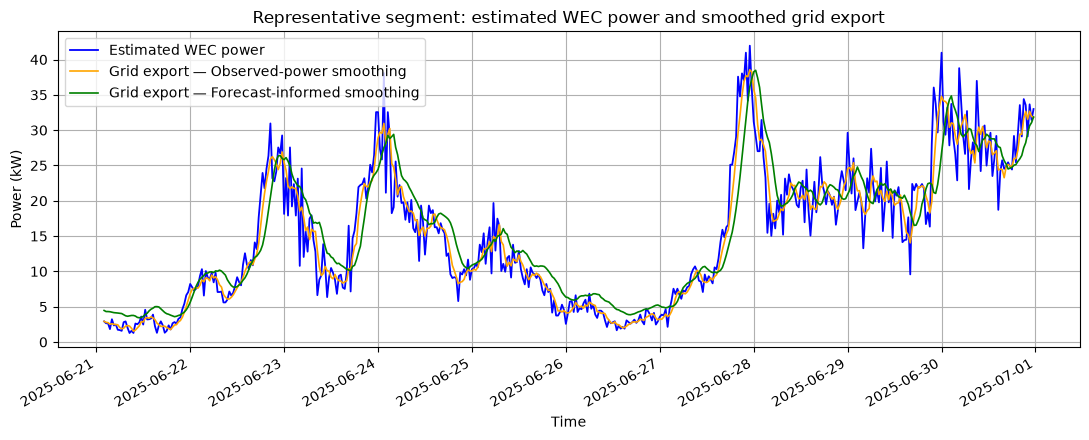

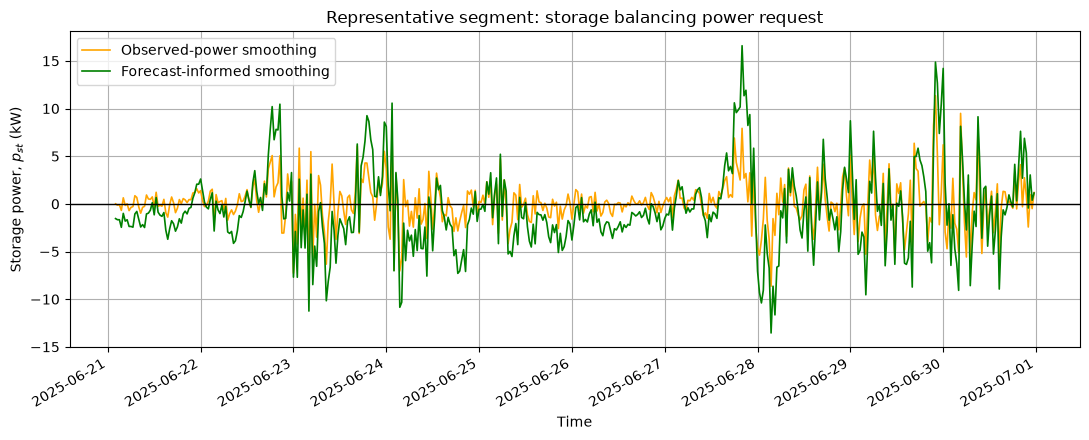

Saved representative-segment figures:

* `../outputs/figures/notebook_06/representative_segment_grid_power.png`
* `../outputs/figures/notebook_06/representative_segment_storage_power.png`

| case                        | start               | end                 |   days |   max \|power\| kW |   usable energy kWh |   throughput kWh |
|:----------------------------|:--------------------|:--------------------|-------:|-------------------:|--------------------:|-----------------:|
| Observed-power smoothing    | 2025-06-21 02:00:00 | 2025-06-30 23:30:00 |   9.92 |              11.35 |               36.05 |           412.3  |
| Forecast-informed smoothing | 2025-06-21 02:00:00 | 2025-06-30 23:30:00 |   9.92 |              16.59 |              189.64 |           751.36 |

In [4]:
TIME_STEP_HOURS = 0.5

REPRESENTATIVE_FOLD_ID = 5
REPRESENTATIVE_SEGMENT_ID = "h1_fold5_seg5"

SCENARIO_COLOR_MAP = {
    "B": "orange",
    "C": "green",
}

representative_segment = selected_timeseries[
    (selected_timeseries["fold_id"] == REPRESENTATIVE_FOLD_ID)
    & (selected_timeseries["segment_id"] == REPRESENTATIVE_SEGMENT_ID)
].copy()

if representative_segment.empty:
    raise ValueError(
        "The selected representative segment was not found in the selected time series."
    )

if representative_segment["scenario"].nunique() != len(SELECTED_SCENARIOS):
    raise ValueError(
        "The representative segment does not contain all selected smoothing scenarios."
    )

representative_segment = representative_segment.sort_values(
    ["scenario", "target_time"]
).reset_index(drop=True)


# Plot WEC power and smoothed grid-export targets.
fig, ax = plt.subplots(figsize=(11, 4.5))

wec_reference = (
    representative_segment
    .drop_duplicates(subset=["target_time"])
    .sort_values("target_time")
)

ax.plot(
    wec_reference["target_time"],
    wec_reference["p_wec_kw"],
    linewidth=1.3,
    color="blue",
    label="Estimated WEC power",
)

for scenario, scenario_df in representative_segment.groupby(
    "scenario",
    observed=True,
):
    scenario_df = scenario_df.sort_values("target_time")
    scenario_name = scenario_df["scenario_name"].iloc[0]

    ax.plot(
        scenario_df["target_time"],
        scenario_df["p_grid_kw"],
        linewidth=1.2,
        color=SCENARIO_COLOR_MAP[scenario],
        label=f"Grid export — {scenario_name}",
    )

ax.set_title("Representative segment: estimated WEC power and smoothed grid export")
ax.set_xlabel("Time")
ax.set_ylabel("Power (kW)")
ax.legend(loc="best")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

grid_power_plot_path = FIGURES_DIR / "representative_segment_grid_power.png"
fig.savefig(grid_power_plot_path, dpi=300, bbox_inches="tight")
plt.show()


# Plot storage balancing power request.
fig, ax = plt.subplots(figsize=(11, 4.5))

for scenario, scenario_df in representative_segment.groupby(
    "scenario",
    observed=True,
):
    scenario_df = scenario_df.sort_values("target_time")
    scenario_name = scenario_df["scenario_name"].iloc[0]

    ax.plot(
        scenario_df["target_time"],
        scenario_df["p_st_kw"],
        linewidth=1.2,
        color=SCENARIO_COLOR_MAP[scenario],
        label=scenario_name,
    )

ax.axhline(0, linewidth=1.0, color="black")
ax.set_title("Representative segment: storage balancing power request")
ax.set_xlabel("Time")
ax.set_ylabel("Storage power, $p_{st}$ (kW)")
ax.legend(loc="best")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

storage_power_plot_path = FIGURES_DIR / "representative_segment_storage_power.png"
fig.savefig(storage_power_plot_path, dpi=300, bbox_inches="tight")
plt.show()


display(
    Markdown(
        "Saved representative-segment figures:\n\n"
        f"* `{grid_power_plot_path}`\n"
        f"* `{storage_power_plot_path}`"
    )
)


representative_segment_summary = (
    representative_segment
    .groupby(["scenario", "scenario_name"], observed=True)
    .agg(
        start_time=("target_time", "min"),
        end_time=("target_time", "max"),
        n_samples=("target_time", "size"),
        max_abs_storage_power_kw=("abs_storage_power_kw", "max"),
        required_energy_kwh=("required_energy_kwh", "max"),
        throughput_kwh=("abs_storage_power_kw", lambda s: s.sum() * TIME_STEP_HOURS),
    )
    .reset_index()
)

representative_segment_summary["duration_hours"] = (
    representative_segment_summary["n_samples"] * TIME_STEP_HOURS
)

representative_segment_summary["duration_days"] = (
    representative_segment_summary["duration_hours"] / 24
)

representative_segment_summary = representative_segment_summary[
    [
        "scenario",
        "scenario_name",
        "start_time",
        "end_time",
        "n_samples",
        "duration_hours",
        "duration_days",
        "max_abs_storage_power_kw",
        "required_energy_kwh",
        "throughput_kwh",
    ]
]

representative_segment_display = representative_segment_summary[
    [
        "scenario_name",
        "start_time",
        "end_time",
        "duration_days",
        "max_abs_storage_power_kw",
        "required_energy_kwh",
        "throughput_kwh",
    ]
].copy()

numeric_cols = representative_segment_display.select_dtypes(include="number").columns
representative_segment_display[numeric_cols] = (
    representative_segment_display[numeric_cols].round(2)
)

representative_segment_display.columns = (
    representative_segment_display.columns
    .str.replace("_", " ", regex=False)
)

representative_segment_display = representative_segment_display.rename(
    columns={
        "scenario name": "case",
        "start time": "start",
        "end time": "end",
        "duration days": "days",
        "max abs storage power kw": "max \\|power\\| kW",
        "required energy kwh": "usable energy kWh",
        "throughput kwh": "throughput kWh",
    }
)

display(Markdown(representative_segment_display.to_markdown(index=False)))

## 5. Simple BESS sizing assumptions

This section defines simple battery-size assumptions for the SimSES replay. The sizing is derived directly from the selected storage-smoothing metrics rather than optimized.

For each selected smoothing case, the battery power rating is based on the maximum storage power requirement across the five rolling-origin folds. The usable energy requirement is also based on the maximum fold-level energy requirement. This keeps the replay conservative relative to the selected evaluation folds.

The assumed SOC operating window is 20–80%. Therefore, the nominal battery energy capacity is larger than the usable energy requirement. The rounded values below are used only to create simple scenario-specific battery configurations for the demonstration.

These assumptions should not be interpreted as optimized BESS sizing. They are transparent replay assumptions for comparing battery operation under the selected WEC smoothing duty cycles.


In [5]:
SOC_MIN = 0.20
SOC_MAX = 0.80
SOC_REFERENCE = 0.50

USABLE_SOC_FRACTION = SOC_MAX - SOC_MIN

POWER_RATING_ROUNDING_KW = 5.0
ENERGY_CAPACITY_ROUNDING_KWH = 10.0

bess_sizing_assumptions = selected_summary[
    [
        "scenario",
        "scenario_name",
        "max_storage_power_rating_kw",
        "max_required_usable_energy_kwh",
    ]
].copy()

bess_sizing_assumptions["soc_min"] = SOC_MIN
bess_sizing_assumptions["soc_max"] = SOC_MAX
bess_sizing_assumptions["usable_soc_fraction"] = USABLE_SOC_FRACTION
bess_sizing_assumptions["reference_soc"] = SOC_REFERENCE

bess_sizing_assumptions["power_rating_kw"] = (
    np.ceil(
        bess_sizing_assumptions["max_storage_power_rating_kw"]
        / POWER_RATING_ROUNDING_KW
    )
    * POWER_RATING_ROUNDING_KW
)

bess_sizing_assumptions["nominal_energy_required_kwh"] = (
    bess_sizing_assumptions["max_required_usable_energy_kwh"]
    / USABLE_SOC_FRACTION
)

bess_sizing_assumptions["nominal_energy_capacity_kwh"] = (
    np.ceil(
        bess_sizing_assumptions["nominal_energy_required_kwh"]
        / ENERGY_CAPACITY_ROUNDING_KWH
    )
    * ENERGY_CAPACITY_ROUNDING_KWH
)

bess_sizing_assumptions["usable_energy_available_kwh"] = (
    bess_sizing_assumptions["nominal_energy_capacity_kwh"]
    * USABLE_SOC_FRACTION
)

bess_sizing_assumptions["usable_energy_margin_kwh"] = (
    bess_sizing_assumptions["usable_energy_available_kwh"]
    - bess_sizing_assumptions["max_required_usable_energy_kwh"]
)

bess_sizing_path = TABLES_DIR / "bess_sizing_assumptions.csv"
bess_sizing_assumptions.to_csv(bess_sizing_path, index=False)

bess_sizing_display = bess_sizing_assumptions[
    [
        "scenario_name",
        "max_storage_power_rating_kw",
        "max_required_usable_energy_kwh",
        "soc_min",
        "soc_max",
        "power_rating_kw",
        "nominal_energy_capacity_kwh",
        "usable_energy_available_kwh",
        "usable_energy_margin_kwh",
    ]
].copy()

numeric_cols = bess_sizing_display.select_dtypes(include="number").columns
bess_sizing_display[numeric_cols] = bess_sizing_display[numeric_cols].round(2)

bess_sizing_display.columns = (
    bess_sizing_display.columns
    .str.replace("_", " ", regex=False)
)

bess_sizing_display = bess_sizing_display.rename(
    columns={
        "scenario name": "case",
        "max storage power rating kw": "max power kw",
        "max required usable energy kwh": "max usable energy kwh",
        "power rating kw": "rounded power kw",
        "nominal energy capacity kwh": "nominal energy kwh",
        "usable energy available kwh": "usable energy kwh",
        "usable energy margin kwh": "energy margin kwh",
    }
)

display(Markdown(bess_sizing_display.to_markdown(index=False)))

| case                        |   max power kw |   max usable energy kwh |   soc min |   soc max |   rounded power kw |   nominal energy kwh |   usable energy kwh |   energy margin kwh |
|:----------------------------|---------------:|------------------------:|----------:|----------:|-------------------:|---------------------:|--------------------:|--------------------:|
| Observed-power smoothing    |          31.39 |                   62.83 |       0.2 |       0.8 |                 35 |                  110 |                  66 |                3.17 |
| Forecast-informed smoothing |          41.41 |                  225.38 |       0.2 |       0.8 |                 45 |                  380 |                 228 |                2.62 |

## 6. Battery replay input profiles

This section converts the selected storage-smoothing profiles into battery replay inputs.

The replay power request preserves the storage sign convention from Notebook 05. Therefore, positive battery-request power means charging, and negative battery-request power means discharging. The power request is stored in both kW and W so that the same table can be used for summary calculations and for the later SimSES replay.

The scenario-specific sizing assumptions from the previous section are merged into the replay profiles. This allows simple stress indicators to be computed before the detailed battery simulation.

The approximate charge and discharge C-rate proxies are computed as:

$C_{charge,proxy} = \frac{\max(p_{bess}, 0)}{E_{nom}}$

$C_{discharge,proxy} = \frac{\max(-p_{bess}, 0)}{E_{nom}}$

where $p_{bess}$ is the requested battery power in kW and $E_{nom}$ is the assumed nominal battery energy capacity in kWh.

These are simple power-to-energy ratios, not detailed electrochemical C-rates from cell current. They are still useful screening indicators: charge-side values describe how strongly the battery is asked to absorb surplus WEC power, while discharge-side values describe how strongly it is asked to support the smoothed grid-export target.

The summary table below describes only the selected representative continuous segment. It is meant to support the detailed replay interpretation in the next sections.

After the table, a 2 × 2 distribution grid is plotted using all selected fold and segment profiles. The first row shows the charge and discharge request distributions, and the second row shows the corresponding charge and discharge C-rate proxy distributions. These plots provide a broader screening view of the requested battery power intensity across the selected evaluation data. The percentages are conditional on active charging or active discharging samples rather than all 30 min samples.

In [6]:
BATTERY_REPLAY_DT_SECONDS = int(TIME_STEP_HOURS * 3600)

sizing_merge_cols = [
    "scenario",
    "power_rating_kw",
    "nominal_energy_capacity_kwh",
    "usable_energy_available_kwh",
    "soc_min",
    "soc_max",
    "reference_soc",
]


representative_replay_profiles = representative_segment.merge(
    bess_sizing_assumptions[sizing_merge_cols],
    on="scenario",
    how="left",
)

representative_replay_profiles["p_bess_request_kw"] = (
    representative_replay_profiles["p_st_kw"]
)

representative_replay_profiles["p_bess_request_w"] = (
    representative_replay_profiles["p_bess_request_kw"] * 1000
)

representative_replay_profiles["dt_seconds"] = BATTERY_REPLAY_DT_SECONDS

representative_replay_profiles["charge_c_rate_proxy"] = (
    representative_replay_profiles["p_bess_request_kw"].clip(lower=0)
    / representative_replay_profiles["nominal_energy_capacity_kwh"]
)

representative_replay_profiles["discharge_c_rate_proxy"] = (
    -representative_replay_profiles["p_bess_request_kw"].clip(upper=0)
    / representative_replay_profiles["nominal_energy_capacity_kwh"]
)


all_replay_profiles = selected_timeseries.merge(
    bess_sizing_assumptions[sizing_merge_cols],
    on="scenario",
    how="left",
)

all_replay_profiles["p_bess_request_kw"] = all_replay_profiles["p_st_kw"]
all_replay_profiles["p_bess_request_w"] = all_replay_profiles["p_bess_request_kw"] * 1000
all_replay_profiles["dt_seconds"] = BATTERY_REPLAY_DT_SECONDS

all_replay_profiles["charge_c_rate_proxy"] = (
    all_replay_profiles["p_bess_request_kw"].clip(lower=0)
    / all_replay_profiles["nominal_energy_capacity_kwh"]
)

all_replay_profiles["discharge_c_rate_proxy"] = (
    -all_replay_profiles["p_bess_request_kw"].clip(upper=0)
    / all_replay_profiles["nominal_energy_capacity_kwh"]
)


representative_replay_path = (
    NOTEBOOK_OUTPUT_DIR
    / "representative_bess_replay_profiles.parquet"
)

all_replay_profiles_path = (
    NOTEBOOK_OUTPUT_DIR
    / "selected_bess_replay_profiles.parquet"
)

representative_replay_profiles.to_parquet(representative_replay_path, index=False)
all_replay_profiles.to_parquet(all_replay_profiles_path, index=False)


replay_input_summary = (
    representative_replay_profiles
    .groupby(["scenario", "scenario_name"], observed=True)
    .agg(
        n_samples=("target_time", "size"),
        duration_days=("dt_seconds", lambda s: s.sum() / (24 * 3600)),
        max_charge_request_kw=("p_bess_request_kw", lambda s: s.clip(lower=0).max()),
        max_discharge_request_kw=("p_bess_request_kw", lambda s: abs(s.clip(upper=0).min())),
        mean_charge_c_rate_proxy=("charge_c_rate_proxy", "mean"),
        p95_charge_c_rate_proxy=("charge_c_rate_proxy", lambda s: s.quantile(0.95)),
        max_charge_c_rate_proxy=("charge_c_rate_proxy", "max"),
        mean_discharge_c_rate_proxy=("discharge_c_rate_proxy", "mean"),
        p95_discharge_c_rate_proxy=("discharge_c_rate_proxy", lambda s: s.quantile(0.95)),
        max_discharge_c_rate_proxy=("discharge_c_rate_proxy", "max"),
    )
    .reset_index()
)

replay_input_display = replay_input_summary[
    [
        "scenario_name",
        "duration_days",
        "max_charge_request_kw",
        "max_discharge_request_kw",
        "p95_charge_c_rate_proxy",
        "max_charge_c_rate_proxy",
        "p95_discharge_c_rate_proxy",
        "max_discharge_c_rate_proxy",
    ]
].copy()

numeric_cols = replay_input_display.select_dtypes(include="number").columns
replay_input_display[numeric_cols] = replay_input_display[numeric_cols].round(3)

replay_input_display.columns = (
    replay_input_display.columns
    .str.replace("_", " ", regex=False)
)

replay_input_display = replay_input_display.rename(
    columns={
        "scenario name": "case",
        "duration days": "days",
        "max charge request kw": "max charge kW",
        "max discharge request kw": "max discharge kW",
        "p95 charge c rate proxy": "p95 charge C",
        "max charge c rate proxy": "max charge C",
        "p95 discharge c rate proxy": "p95 discharge C",
        "max discharge c rate proxy": "max discharge C",
    }
)

display(Markdown(replay_input_display.to_markdown(index=False)))

| case                        |   days |   max charge kW |   max discharge kW |   p95 charge C |   max charge C |   p95 discharge C |   max discharge C |
|:----------------------------|-------:|----------------:|-------------------:|---------------:|---------------:|------------------:|------------------:|
| Observed-power smoothing    |  9.917 |          11.353 |              8.638 |          0.038 |          0.103 |             0.036 |             0.079 |
| Forecast-informed smoothing |  9.917 |          16.591 |             13.546 |          0.021 |          0.044 |             0.018 |             0.036 |

The representative segment shows relatively modest battery power intensity under the simple sizing assumptions used here. For the detailed 9.9-day segment, the observed-power smoothing case reaches about 11.4 kW charge request and 8.6 kW discharge request, while the forecast-informed case reaches about 16.6 kW charge request and 13.5 kW discharge request. The corresponding C-rate proxies remain low because the assumed nominal battery capacities are sized conservatively from the maximum fold-level energy requirements.

Across all selected fold and segment replay profiles, most active charge and discharge samples are concentrated near low power requests and low C-rate proxies. The long right tails indicate that occasional higher-intensity charge or discharge events are still present. These tail events are important for later interpretation because they can contribute disproportionately to battery stress, even when the typical operating point is mild.

The forecast-informed smoothing profile shows a somewhat broader request distribution than the observed-power smoothing profile, especially on the charge side. This is consistent with the earlier storage-smoothing results: forecast-informed smoothing can create larger storage mismatch when the smoothed grid target follows forecasted rather than observed WEC power. These distributions should be read as screening indicators of the requested duty cycle, not as final degradation results.

## 7. SimSES battery configuration

This section defines the simple SimSES battery configurations used for the replay. SimSES represents the battery as a series-parallel cell circuit and advances the battery state from a signed power setpoint. In the SimSES sign convention, positive power means charging and negative power means discharging, which matches the storage-power convention used in this notebook.

The physical electrical chain of a grid-connected WEC–BESS system would normally include generator-side power electronics, rectification or DC-link coupling, battery conversion stages, and grid-side inversion. This notebook does not model that full converter chain. Instead, the storage profile from Notebook 05 is treated as a net battery-side power request required to buffer the difference between estimated WEC power and the selected smoothed grid-export target.

This simplification keeps the demonstration focused on battery operation under the implied smoothing duty cycle. Converter efficiencies, detailed AC/DC coupling, grid-code controls, and plant-level electrical architecture are therefore left outside the scope of this notebook and should be considered in a more detailed design study.

For this demonstration, a Sony LFP cell model available in SimSES is used with scenario-specific parallel cell counts chosen to approximately match the nominal energy capacities defined above. The number of series cells is fixed as a simple representative DC-link-scale assumption, while the number of parallel cells is rounded upward to satisfy the target nominal energy capacity.

SimSES is used here mainly for the battery electrical and degradation-related replay. For temperature, a simple lumped thermal post-processing model is applied later using the simulated battery heat signal. This thermal model is intended only as an illustrative response model, not as a validated thermal-management or cooling-system design.

The resulting battery configurations are therefore transparent simulation assumptions, not proposed engineering designs.

In [7]:
from simses.battery import Battery
from simses.model.cell.sony_lfp import SonyLFP


SIMSES_SERIES_CELLS = 200
SIMSES_START_TEMPERATURE_C = 25.0
SIMSES_USE_DEGRADATION = True

THERMAL_MODEL_AMBIENT_TEMPERATURE_C = 25.0
THERMAL_MODEL_INITIAL_TEMPERATURE_C = 25.0
THERMAL_MODEL_RESISTANCE_K_PER_KW = 2.0
THERMAL_MODEL_CAPACITY_KWH_PER_K = 3.0


def make_simses_battery(
    nominal_energy_capacity_kwh,
    start_soc=0.50,
    soc_limits=(0.20, 0.80),
    start_temperature_c=25.0,
    n_series=200,
    use_degradation=True,
):
    """Create a simple SimSES Sony LFP battery sized by nominal energy."""
    cell = SonyLFP()

    cell_nominal_energy_wh = (
        cell.electrical.nominal_voltage
        * cell.electrical.nominal_capacity
    )

    target_energy_wh = nominal_energy_capacity_kwh * 1000

    n_parallel = int(
        np.ceil(target_energy_wh / (cell_nominal_energy_wh * n_series))
    )

    n_parallel = max(n_parallel, 1)

    battery = Battery(
        cell=cell,
        circuit=(n_series, n_parallel),
        initial_states={
            "start_soc": start_soc,
            "start_T": start_temperature_c,
        },
        soc_limits=soc_limits,
        degradation=use_degradation,
    )

    return battery, n_series, n_parallel


simses_config_rows = []

for _, row in bess_sizing_assumptions.iterrows():
    battery, n_series, n_parallel = make_simses_battery(
        nominal_energy_capacity_kwh=row["nominal_energy_capacity_kwh"],
        start_soc=row["reference_soc"],
        soc_limits=(row["soc_min"], row["soc_max"]),
        start_temperature_c=SIMSES_START_TEMPERATURE_C,
        n_series=SIMSES_SERIES_CELLS,
        use_degradation=SIMSES_USE_DEGRADATION,
    )

    simses_config_rows.append(
        {
            "scenario": row["scenario"],
            "scenario_name": row["scenario_name"],
            "target_nominal_energy_capacity_kwh": row["nominal_energy_capacity_kwh"],
            "simses_nominal_energy_capacity_kwh": (
                battery.nominal_energy_capacity / 1000
            ),
            "power_rating_kw": row["power_rating_kw"],
            "series_cells": n_series,
            "parallel_cells": n_parallel,
            "nominal_voltage_v": battery.nominal_voltage,
            "nominal_capacity_ah": battery.nominal_capacity,
            "soc_min": row["soc_min"],
            "soc_max": row["soc_max"],
            "start_soc": row["reference_soc"],
            "start_temperature_c": SIMSES_START_TEMPERATURE_C,
            "degradation_enabled": SIMSES_USE_DEGRADATION,
        }
    )

simses_battery_config = pd.DataFrame(simses_config_rows)

simses_battery_config["storage_duration_h"] = (
    simses_battery_config["simses_nominal_energy_capacity_kwh"]
    / simses_battery_config["power_rating_kw"]
)

simses_battery_config_path = (
    TABLES_DIR
    / "simses_battery_configuration.csv"
)

simses_battery_config.to_csv(simses_battery_config_path, index=False)

simses_battery_config = simses_battery_config[
    [
        "scenario",
        "scenario_name",
        "target_nominal_energy_capacity_kwh",
        "simses_nominal_energy_capacity_kwh",
        "power_rating_kw",
        "storage_duration_h",
        "series_cells",
        "parallel_cells",
        "nominal_voltage_v",
        "nominal_capacity_ah",
        "soc_min",
        "soc_max",
        "start_soc",
        "start_temperature_c",
        "degradation_enabled",
    ]
]

simses_battery_config_display = simses_battery_config[
    [
        "scenario_name",
        "simses_nominal_energy_capacity_kwh",
        "power_rating_kw",
        "storage_duration_h",
        "series_cells",
        "parallel_cells",
        "nominal_voltage_v",
        "nominal_capacity_ah",
        "soc_min",
        "soc_max",
        "degradation_enabled",
    ]
].copy()

numeric_cols = simses_battery_config_display.select_dtypes(include="number").columns
simses_battery_config_display[numeric_cols] = (
    simses_battery_config_display[numeric_cols].round(2)
)

simses_battery_config_display.columns = (
    simses_battery_config_display.columns
    .str.replace("_", " ", regex=False)
)

simses_battery_config_display = simses_battery_config_display.rename(
    columns={
        "scenario name": "case",
        "simses nominal energy capacity kwh": "SimSES energy kWh",
        "power rating kw": "power kW",
        "storage duration h": "duration h",
        "series cells": "series cells",
        "parallel cells": "parallel cells",
        "nominal voltage v": "voltage V",
        "nominal capacity ah": "capacity Ah",
        "soc min": "SOC min",
        "soc max": "SOC max",
        "degradation enabled": "degradation",
    }
)

display(Markdown(simses_battery_config_display.to_markdown(index=False)))

| case                        |   SimSES energy kWh |   power kW |   duration h |   series cells |   parallel cells |   voltage V |   capacity Ah |   SOC min |   SOC max | degradation   |
|:----------------------------|--------------------:|-----------:|-------------:|---------------:|-----------------:|------------:|--------------:|----------:|----------:|:--------------|
| Observed-power smoothing    |              111.36 |         35 |         3.18 |            200 |               58 |         640 |           174 |       0.2 |       0.8 | True          |
| Forecast-informed smoothing |              380.16 |         45 |         8.45 |            200 |              198 |         640 |           594 |       0.2 |       0.8 | True          |

The implied storage duration is computed as nominal energy capacity divided by power rating. The observed-power smoothing configuration is about 3.2 h, while the forecast-informed smoothing configuration is about 8.4 h.

The resulting configurations are small compared with many grid-scale BESS installations, but they are not fictional. For example, the [European Commission BRIDGE BESS case study](https://bridge-smart-grid-storage-systems-digital-projects.ec.europa.eu/sites/default/files/case-studies/03_BESS_Case%20study_v2.pdf) reports real demonstration systems ranging from smaller systems such as 30 kW / 43 kWh and 50 kW / 200 kWh to larger systems such as 720 kW / 560 kWh, 1 MW / 2 MWh, and above. In that context, the configurations used here are best interpreted as small demonstration or site-level BESS assumptions rather than plant-scale designs.

The nominal voltage and capacity shown in the table are SimSES equivalent-pack values resulting from the chosen series-parallel Sony LFP cell scaling. A nominal voltage around 640 V is within the voltage range discussed for stationary energy-storage batteries; [IEC 63056](https://webstore.iec.ch/en/publication/29224) specifies safety requirements for secondary lithium batteries used in electrical energy storage systems up to 1500 V DC. The ampere-hour values should not be read as a commercial rack specification, but as internal equivalent-pack capacities used by the simulation model.

These configurations are therefore physically plausible as transparent simulation assumptions for replaying the selected WEC smoothing duty cycles, but they should not be interpreted as proposed BESS designs.

Later in the notebook, temperature is not taken directly from an internal SimSES thermal evolution. Instead, a simple lumped thermal post-processing model is used with an ambient temperature of 25 °C, initial temperature of 25 °C, thermal resistance of 2 K / kW, and thermal capacity of 3 kWh / K. This is intended only to illustrate possible temperature response under the replayed duty cycle.

## 8. Representative SimSES replay results

This section summarizes the representative SimSES replay for the selected continuous segment.

For each smoothing case, the initial SOC is chosen so that the cumulative net-energy swing of the replay is centered within the assumed 20–80% SOC operating window. This avoids turning an arbitrary initial SOC choice into artificial early clipping. The replay still reports the actually delivered SimSES battery power, so any power limitation or tracking mismatch remains visible.

The figure below shows the main battery-side time-series outputs for the two smoothing cases. The simulated and requested battery powers are shown in separate panels to make their comparison clearer. The remaining panels show SOC evolution, cumulative throughput, an illustrative lumped thermal response, and the available SimSES state-of-health indicators.

The thermal panel is not a detailed internal SimSES thermal simulation. Instead, it is a simple post-processing model driven by the simulated battery heat signal and first-order heat loss to a fixed ambient temperature. It is included only to provide an interpretable temperature-response illustration under the replayed duty cycle.

The cumulative-throughput panel also reports the final equivalent full cycles reached over the representative replay window. These values are used only as compact duty-cycle indicators for the selected segment, not as lifetime predictions.

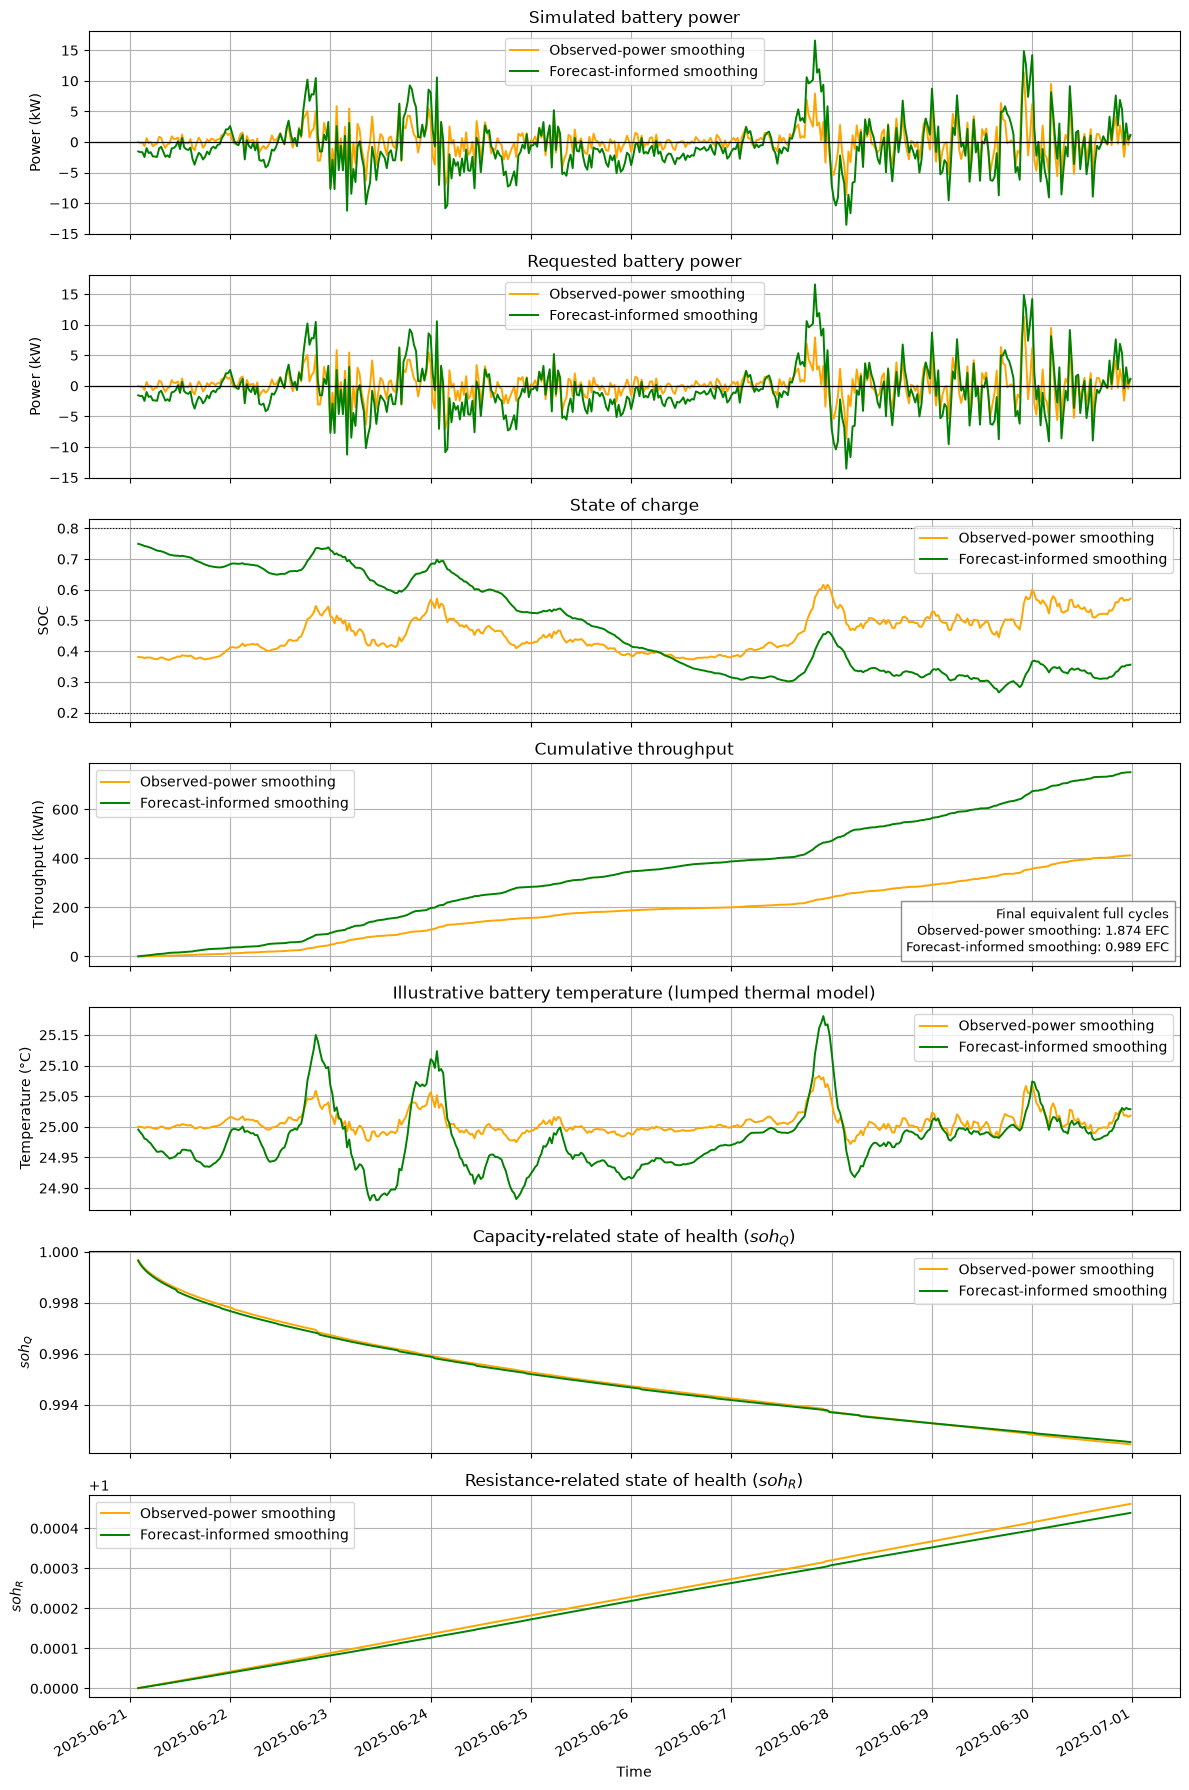

Saved representative SimSES replay outputs:

* `../outputs/notebook_06/representative_simses_replay_results.parquet`
* `../outputs/tables/notebook_06/representative_simses_replay_metadata.csv`
* `../outputs/tables/notebook_06/representative_simses_replay_summary.csv`
* `../outputs/figures/notebook_06/representative_simses_replay_results.png`

In [8]:
representative_simses_results = []
representative_replay_metadata_rows = []

for scenario in SELECTED_SCENARIOS:
    scenario_profile = (
        representative_replay_profiles[
            representative_replay_profiles["scenario"] == scenario
        ]
        .sort_values("target_time")
        .reset_index(drop=True)
    )

    sizing_row = bess_sizing_assumptions[
        bess_sizing_assumptions["scenario"] == scenario
    ].iloc[0]

    start_soc = compute_energy_balanced_start_soc(
        power_kw=scenario_profile["p_bess_request_kw"],
        dt_hours=TIME_STEP_HOURS,
        nominal_energy_capacity_kwh=sizing_row["nominal_energy_capacity_kwh"],
        soc_min=sizing_row["soc_min"],
        soc_max=sizing_row["soc_max"],
    )

    battery, n_series, n_parallel = make_simses_battery(
        nominal_energy_capacity_kwh=sizing_row["nominal_energy_capacity_kwh"],
        start_soc=start_soc,
        soc_limits=(sizing_row["soc_min"], sizing_row["soc_max"]),
        start_temperature_c=SIMSES_START_TEMPERATURE_C,
        n_series=SIMSES_SERIES_CELLS,
        use_degradation=SIMSES_USE_DEGRADATION,
    )

    scenario_result = replay_simses_profile(
        profile_df=scenario_profile,
        battery=battery,
        nominal_energy_capacity_kwh=sizing_row["nominal_energy_capacity_kwh"],
    )

    thermal_input_kw = scenario_result["heat_kw"].copy()

    if thermal_input_kw.isna().all() or np.isclose(thermal_input_kw.abs().sum(), 0.0):
        thermal_input_kw = scenario_result["loss_kw"].copy()

    scenario_result["temperature_model_c"] = simulate_lumped_temperature_response(
        heat_kw=thermal_input_kw,
        dt_seconds=BATTERY_REPLAY_DT_SECONDS,
        ambient_temperature_c=THERMAL_MODEL_AMBIENT_TEMPERATURE_C,
        initial_temperature_c=THERMAL_MODEL_INITIAL_TEMPERATURE_C,
        thermal_resistance_k_per_kw=THERMAL_MODEL_RESISTANCE_K_PER_KW,
        thermal_capacity_kwh_per_k=THERMAL_MODEL_CAPACITY_KWH_PER_K,
    )

    representative_simses_results.append(scenario_result)

    representative_replay_metadata_rows.append(
        {
            "scenario": scenario,
            "scenario_name": scenario_profile["scenario_name"].iloc[0],
            "start_soc": start_soc,
            "series_cells": n_series,
            "parallel_cells": n_parallel,
            "nominal_energy_capacity_kwh": sizing_row["nominal_energy_capacity_kwh"],
            "power_rating_kw": sizing_row["power_rating_kw"],
            "n_samples": len(scenario_profile),
            "duration_days": scenario_profile["dt_seconds"].sum() / (24 * 3600),
        }
    )

representative_simses_results = pd.concat(
    representative_simses_results,
    ignore_index=True,
)

representative_replay_metadata = pd.DataFrame(
    representative_replay_metadata_rows
)

representative_simses_results_path = (
    NOTEBOOK_OUTPUT_DIR
    / "representative_simses_replay_results.parquet"
)

representative_replay_metadata_path = (
    TABLES_DIR
    / "representative_simses_replay_metadata.csv"
)

representative_simses_results.to_parquet(
    representative_simses_results_path,
    index=False,
)

representative_replay_metadata.to_csv(
    representative_replay_metadata_path,
    index=False,
)


representative_simses_summary = (
    representative_simses_results
    .groupby(["scenario", "scenario_name"], observed=True)
    .agg(
        throughput_kwh=("throughput_increment_kwh", "sum"),
        final_equivalent_full_cycles=("equivalent_full_cycles", "max"),
        max_abs_power_tracking_error_kw=(
            "p_tracking_error_kw",
            lambda s: s.abs().max(),
        ),
        soc_min=("soc", "min"),
        soc_max=("soc", "max"),
        temperature_model_max_c=("temperature_model_c", "max"),
        final_soh_Q=("soh_Q", "last"),
        final_soh_R=("soh_R", "last"),
    )
    .reset_index()
)

representative_simses_summary = representative_simses_summary.merge(
    representative_replay_metadata[
        [
            "scenario",
            "start_soc",
            "nominal_energy_capacity_kwh",
            "power_rating_kw",
            "duration_days",
        ]
    ],
    on="scenario",
    how="left",
)

representative_simses_summary["delta_soh_Q"] = (
    1.0 - representative_simses_summary["final_soh_Q"]
)

representative_simses_summary["delta_soh_R"] = (
    representative_simses_summary["final_soh_R"] - 1.0
)

representative_simses_summary_path = (
    TABLES_DIR
    / "representative_simses_replay_summary.csv"
)

representative_simses_summary.to_csv(
    representative_simses_summary_path,
    index=False,
)


efc_summary = representative_simses_summary[
    ["scenario", "scenario_name", "final_equivalent_full_cycles"]
].copy()

efc_text_lines = []
for _, row in efc_summary.iterrows():
    efc_text_lines.append(
        f"{row['scenario_name']}: {row['final_equivalent_full_cycles']:.3f} EFC"
    )

efc_text = "Final equivalent full cycles\n" + "\n".join(efc_text_lines)


representative_results_figure_path = (
    FIGURES_DIR
    / "representative_simses_replay_results.png"
)

fig, axes = plt.subplots(7, 1, figsize=(12, 18), sharex=True)

for scenario, scenario_df in representative_simses_results.groupby(
    "scenario",
    observed=True,
):
    scenario_df = scenario_df.sort_values("target_time")
    scenario_name = scenario_df["scenario_name"].iloc[0]
    color = SCENARIO_COLOR_MAP[scenario]

    # Simulated battery power
    axes[0].plot(
        scenario_df["target_time"],
        scenario_df["p_bess_actual_kw"],
        color=color,
        linewidth=1.4,
        label=scenario_name,
    )

    # Requested battery power
    axes[1].plot(
        scenario_df["target_time"],
        scenario_df["p_bess_request_kw"],
        color=color,
        linewidth=1.4,
        label=scenario_name,
    )

    # SOC
    axes[2].plot(
        scenario_df["target_time"],
        scenario_df["soc"],
        color=color,
        linewidth=1.4,
        label=scenario_name,
    )

    # Cumulative throughput
    axes[3].plot(
        scenario_df["target_time"],
        scenario_df["cumulative_throughput_kwh"],
        color=color,
        linewidth=1.4,
        label=scenario_name,
    )

    # Illustrative thermal response
    axes[4].plot(
        scenario_df["target_time"],
        scenario_df["temperature_model_c"],
        color=color,
        linewidth=1.4,
        label=scenario_name,
    )

    # soh_Q
    axes[5].plot(
        scenario_df["target_time"],
        scenario_df["soh_Q"],
        color=color,
        linewidth=1.4,
        label=scenario_name,
    )

    # soh_R
    axes[6].plot(
        scenario_df["target_time"],
        scenario_df["soh_R"],
        color=color,
        linewidth=1.4,
        label=scenario_name,
    )

axes[0].axhline(0, color="black", linewidth=0.9)
axes[0].set_title("Simulated battery power")
axes[0].set_ylabel("Power (kW)")
axes[0].legend(loc="best")

axes[1].axhline(0, color="black", linewidth=0.9)
axes[1].set_title("Requested battery power")
axes[1].set_ylabel("Power (kW)")
axes[1].legend(loc="best")

axes[2].axhline(SOC_MIN, color="black", linewidth=0.8, linestyle=":")
axes[2].axhline(SOC_MAX, color="black", linewidth=0.8, linestyle=":")
axes[2].set_title("State of charge")
axes[2].set_ylabel("SOC")
axes[2].legend(loc="best")

axes[3].set_title("Cumulative throughput")
axes[3].set_ylabel("Throughput (kWh)")
axes[3].legend(loc="best")
axes[3].text(
    0.99,
    0.05,
    efc_text,
    transform=axes[3].transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(facecolor="white", edgecolor="gray", alpha=0.9),
)

axes[4].set_title("Illustrative battery temperature (lumped thermal model)")
axes[4].set_ylabel("Temperature (°C)")
axes[4].legend(loc="best")

axes[5].set_title("Capacity-related state of health ($soh_Q$)")
axes[5].set_ylabel("$soh_Q$")
axes[5].legend(loc="best")

axes[6].set_title("Resistance-related state of health ($soh_R$)")
axes[6].set_ylabel("$soh_R$")
axes[6].set_xlabel("Time")
axes[6].legend(loc="best")

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()
fig.savefig(representative_results_figure_path, dpi=300, bbox_inches="tight")
plt.show()

display(
    Markdown(
        "Saved representative SimSES replay outputs:\n\n"
        f"* `{representative_simses_results_path}`\n"
        f"* `{representative_replay_metadata_path}`\n"
        f"* `{representative_simses_summary_path}`\n"
        f"* `{representative_results_figure_path}`"
    )
)

For the representative segment, the simulated battery power follows the requested battery power closely, with no visible tracking limitation. This indicates that, under the simple scenario-specific SimSES configurations used here, the battery can absorb and deliver the requested smoothing power without apparent clipping over this replay window. This result is conditional on the assumed battery sizes, SOC limits, and initial SOC-centering approach.

The SOC trajectories show that the two smoothing strategies use the energy buffer differently. The observed-power smoothing case remains mostly in the middle of the 20–80% SOC window, while the forecast-informed smoothing case starts higher and moves toward lower SOC values over the segment.

The cumulative-throughput panel shows that the forecast-informed case moves more energy in absolute terms over this representative window. However, because the forecast-informed case is paired with a larger nominal battery capacity, its equivalent full cycles are lower: about 0.99 EFC compared with about 1.87 EFC for the observed-power case. This is why throughput and equivalent full cycles should be interpreted together.

The illustrative thermal response remains modest under the simple lumped thermal assumptions. These temperatures should be interpreted only as a transparent post-processing illustration driven by the replayed heat/loss signal, not as a validated thermal-management result.

The $soh_Q$ and $soh_R$ trajectories show small monotonic changes during the replay. These are useful as degradation-relevant indicators for comparing duty cycles, but they should not be interpreted as lifetime predictions or validated aging estimates.

## 9. Independent replay across selected folds and segments

The representative segment above gives an intuitive time-series view of battery operation. This section extends the replay to all selected fold and segment profiles for the two smoothing cases.

The rolling-origin folds overlap in calendar time, and the continuous segments have different durations. Therefore, the profiles are not concatenated into one artificial lifetime trajectory. Instead, each scenario–fold–segment profile is replayed independently, with the battery state reset at the start of each replay.

The summary indicators are reported using duration-normalized quantities such as throughput per day and equivalent full cycles per day. These metrics are intended as screening indicators of duty-cycle intensity, not as direct lifetime predictions.

The figure below summarizes segment-level replay indicators across the independently replayed fold/segment profiles. Segment duration is shown once because both smoothing cases use the same underlying fold/segment structure. The remaining panels compare the two smoothing cases using SOC range, duration-normalized cycling indicators, C-rate proxies, illustrative temperature rise, and capacity-loss indicators.

The “maximum illustrative temperature rise” is computed as the maximum temperature increase above the assumed 25 °C ambient temperature in the simple lumped thermal post-processing model. It is included as a transparent thermal-response indicator driven by the replayed heat/loss signal, not as a validated thermal-management result.

**Note:**

Across the independently replayed profiles, the maximum battery power-tracking error was effectively zero for both selected smoothing cases. This means the simulated batteries were able to follow the requested power profiles under the current sizing assumptions, so tracking error is not shown as a separate result panel.

| case                        |   segments |   median SOC range |   p95 SOC range |   median kWh/day |   p95 kWh/day |   median EFC/day |   p95 EFC/day |   max tracking error kW |   max temp °C |
|:----------------------------|-----------:|-------------------:|----------------:|-----------------:|--------------:|-----------------:|--------------:|------------------------:|--------------:|
| Observed-power smoothing    |         38 |              0.205 |          0.5473 |          51.5597 |       173.476 |           0.2344 |        0.7885 |                       0 |       25.2516 |
| Forecast-informed smoothing |         38 |              0.218 |          0.5669 |         134.82   |       241.676 |           0.1774 |        0.318  |                       0 |       25.431  |

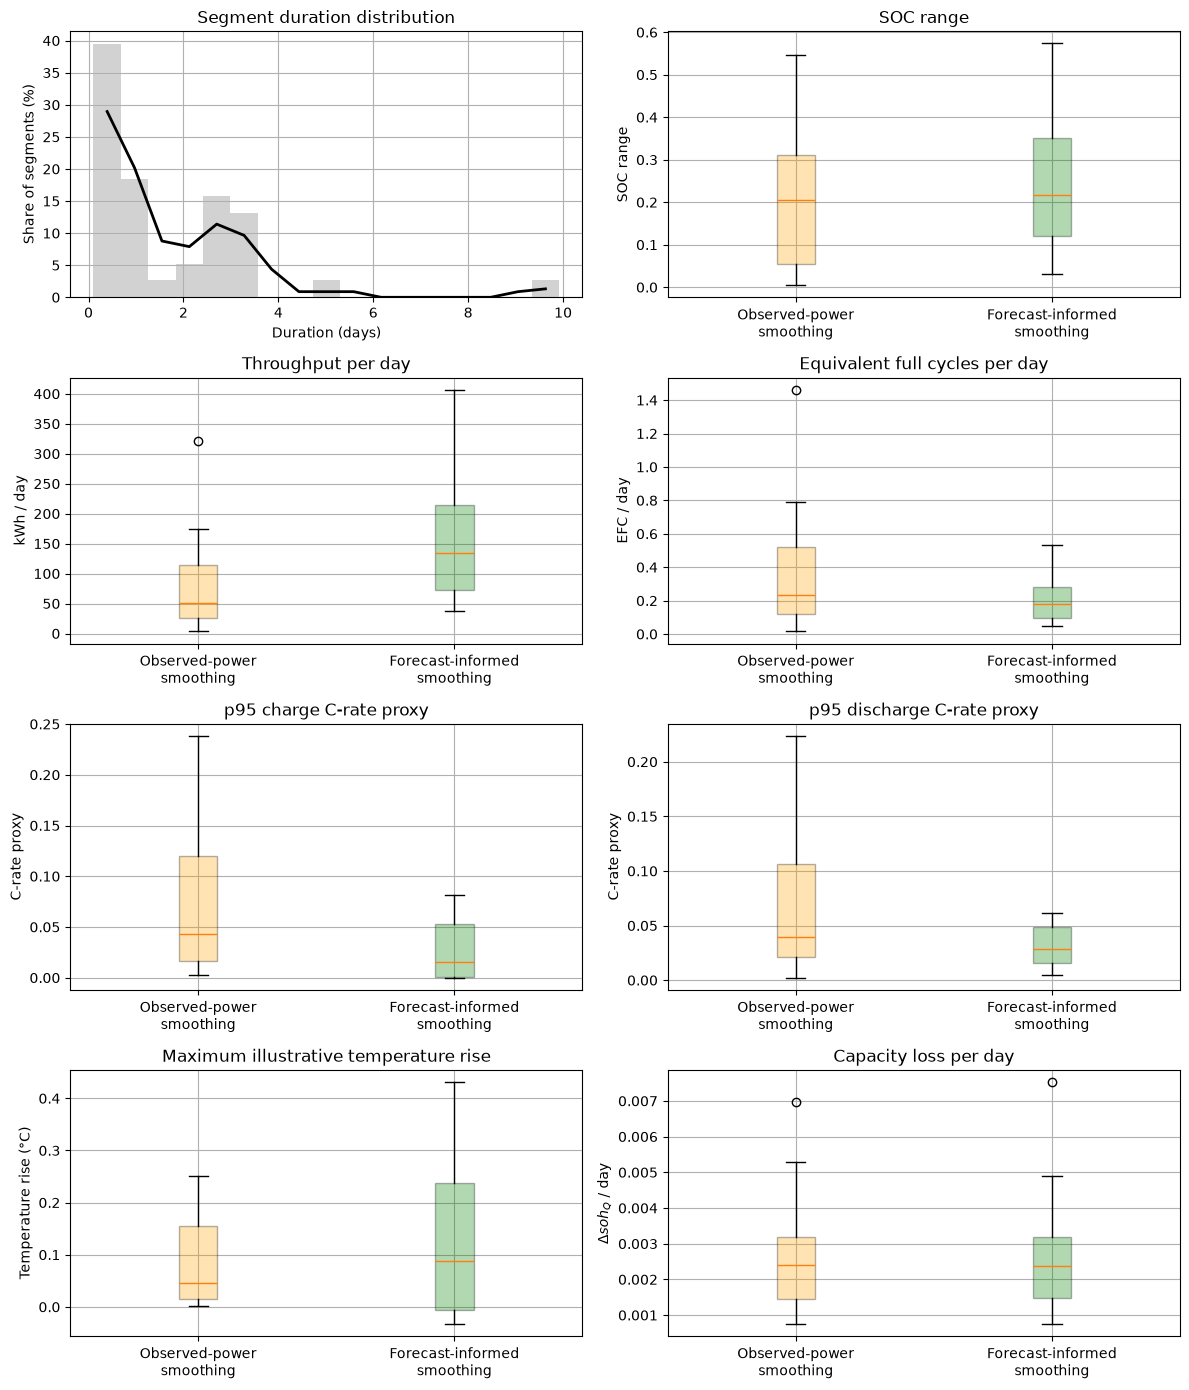

Saved cross-segment screening figure:

* `../outputs/figures/notebook_06/cross_segment_simses_screening_distributions.png`

In [9]:
all_simses_results = []
all_replay_metadata_rows = []

segment_group_cols = [
    "scenario",
    "scenario_name",
    "fold_id",
    "segment_id",
]

for group_key, segment_profile in all_replay_profiles.groupby(
    segment_group_cols,
    observed=True,
):
    scenario, scenario_name, fold_id, segment_id = group_key

    segment_profile = (
        segment_profile
        .sort_values("target_time")
        .reset_index(drop=True)
    )

    sizing_row = bess_sizing_assumptions[
        bess_sizing_assumptions["scenario"] == scenario
    ].iloc[0]

    start_soc = compute_energy_balanced_start_soc(
        power_kw=segment_profile["p_bess_request_kw"],
        dt_hours=TIME_STEP_HOURS,
        nominal_energy_capacity_kwh=sizing_row["nominal_energy_capacity_kwh"],
        soc_min=sizing_row["soc_min"],
        soc_max=sizing_row["soc_max"],
    )

    battery, n_series, n_parallel = make_simses_battery(
        nominal_energy_capacity_kwh=sizing_row["nominal_energy_capacity_kwh"],
        start_soc=start_soc,
        soc_limits=(sizing_row["soc_min"], sizing_row["soc_max"]),
        start_temperature_c=SIMSES_START_TEMPERATURE_C,
        n_series=SIMSES_SERIES_CELLS,
        use_degradation=SIMSES_USE_DEGRADATION,
    )

    segment_result = replay_simses_profile(
        profile_df=segment_profile,
        battery=battery,
        nominal_energy_capacity_kwh=sizing_row["nominal_energy_capacity_kwh"],
    )

    thermal_input_kw = segment_result["heat_kw"].copy()

    if thermal_input_kw.isna().all() or np.isclose(thermal_input_kw.abs().sum(), 0.0):
        thermal_input_kw = segment_result["loss_kw"].copy()

    segment_result["temperature_model_c"] = simulate_lumped_temperature_response(
        heat_kw=thermal_input_kw,
        dt_seconds=BATTERY_REPLAY_DT_SECONDS,
        ambient_temperature_c=THERMAL_MODEL_AMBIENT_TEMPERATURE_C,
        initial_temperature_c=THERMAL_MODEL_INITIAL_TEMPERATURE_C,
        thermal_resistance_k_per_kw=THERMAL_MODEL_RESISTANCE_K_PER_KW,
        thermal_capacity_kwh_per_k=THERMAL_MODEL_CAPACITY_KWH_PER_K,
    )

    segment_result["nominal_energy_capacity_kwh"] = (
        sizing_row["nominal_energy_capacity_kwh"]
    )

    segment_result["power_rating_kw"] = sizing_row["power_rating_kw"]
    segment_result["start_soc"] = start_soc

    segment_result["charge_c_rate_proxy"] = (
        segment_result["p_bess_request_kw"].clip(lower=0)
        / sizing_row["nominal_energy_capacity_kwh"]
    )

    segment_result["discharge_c_rate_proxy"] = (
        -segment_result["p_bess_request_kw"].clip(upper=0)
        / sizing_row["nominal_energy_capacity_kwh"]
    )

    all_simses_results.append(segment_result)

    all_replay_metadata_rows.append(
        {
            "scenario": scenario,
            "scenario_name": scenario_name,
            "fold_id": fold_id,
            "segment_id": segment_id,
            "start_time": segment_profile["target_time"].min(),
            "end_time": segment_profile["target_time"].max(),
            "start_soc": start_soc,
            "series_cells": n_series,
            "parallel_cells": n_parallel,
            "nominal_energy_capacity_kwh": sizing_row["nominal_energy_capacity_kwh"],
            "power_rating_kw": sizing_row["power_rating_kw"],
            "n_samples": len(segment_profile),
            "duration_days": segment_profile["dt_seconds"].sum() / (24 * 3600),
        }
    )


all_simses_results = pd.concat(
    all_simses_results,
    ignore_index=True,
)

all_replay_metadata = pd.DataFrame(all_replay_metadata_rows)


all_simses_results_path = (
    NOTEBOOK_OUTPUT_DIR
    / "all_selected_simses_replay_results.parquet"
)

all_replay_metadata_path = (
    TABLES_DIR
    / "all_selected_simses_replay_metadata.csv"
)

all_simses_results.to_parquet(
    all_simses_results_path,
    index=False,
)

all_replay_metadata.to_csv(
    all_replay_metadata_path,
    index=False,
)


all_segment_simses_summary = (
    all_simses_results
    .groupby(segment_group_cols, observed=True)
    .agg(
        start_time=("target_time", "min"),
        end_time=("target_time", "max"),
        n_samples=("target_time", "size"),
        duration_days=("dt_seconds", lambda s: s.sum() / (24 * 3600)),
        soc_min=("soc", "min"),
        soc_max=("soc", "max"),
        throughput_kwh=("throughput_increment_kwh", "sum"),
        final_equivalent_full_cycles=("equivalent_full_cycles", "max"),
        mean_charge_c_rate_proxy=("charge_c_rate_proxy", "mean"),
        p95_charge_c_rate_proxy=("charge_c_rate_proxy", lambda s: s.quantile(0.95)),
        mean_discharge_c_rate_proxy=("discharge_c_rate_proxy", "mean"),
        p95_discharge_c_rate_proxy=("discharge_c_rate_proxy", lambda s: s.quantile(0.95)),
        max_abs_power_tracking_error_kw=(
            "p_tracking_error_kw",
            lambda s: s.abs().max(),
        ),
        max_temperature_model_c=("temperature_model_c", "max"),
        final_soh_Q=("soh_Q", "last"),
        final_soh_R=("soh_R", "last"),
    )
    .reset_index()
)

all_segment_simses_summary["soc_range"] = (
    all_segment_simses_summary["soc_max"]
    - all_segment_simses_summary["soc_min"]
)

all_segment_simses_summary["throughput_kwh_per_day"] = (
    all_segment_simses_summary["throughput_kwh"]
    / all_segment_simses_summary["duration_days"]
)

all_segment_simses_summary["equivalent_full_cycles_per_day"] = (
    all_segment_simses_summary["final_equivalent_full_cycles"]
    / all_segment_simses_summary["duration_days"]
)

all_segment_simses_summary["delta_soh_Q"] = (
    1.0 - all_segment_simses_summary["final_soh_Q"]
)

all_segment_simses_summary["delta_soh_R"] = (
    all_segment_simses_summary["final_soh_R"] - 1.0
)

all_segment_simses_summary["delta_soh_Q_per_day"] = (
    all_segment_simses_summary["delta_soh_Q"]
    / all_segment_simses_summary["duration_days"]
)

all_segment_simses_summary["delta_soh_R_per_day"] = (
    all_segment_simses_summary["delta_soh_R"]
    / all_segment_simses_summary["duration_days"]
)


all_segment_simses_summary_path = (
    TABLES_DIR
    / "all_selected_simses_segment_summary.csv"
)

all_segment_simses_summary.to_csv(
    all_segment_simses_summary_path,
    index=False,
)


cross_segment_summary = (
    all_segment_simses_summary
    .groupby(["scenario", "scenario_name"], observed=True)
    .agg(
        n_segments=("segment_id", "nunique"),
        median_duration_days=("duration_days", "median"),
        median_soc_range=("soc_range", "median"),
        p95_soc_range=("soc_range", lambda s: s.quantile(0.95)),
        median_throughput_kwh_per_day=("throughput_kwh_per_day", "median"),
        p95_throughput_kwh_per_day=("throughput_kwh_per_day", lambda s: s.quantile(0.95)),
        median_efc_per_day=("equivalent_full_cycles_per_day", "median"),
        p95_efc_per_day=("equivalent_full_cycles_per_day", lambda s: s.quantile(0.95)),
        max_power_tracking_error_kw=("max_abs_power_tracking_error_kw", "max"),
        median_temperature_model_max_c=("max_temperature_model_c", "median"),
        max_temperature_model_max_c=("max_temperature_model_c", "max"),
        median_delta_soh_Q_per_day=("delta_soh_Q_per_day", "median"),
        median_delta_soh_R_per_day=("delta_soh_R_per_day", "median"),
    )
    .reset_index()
)

cross_segment_summary_path = (
    TABLES_DIR
    / "cross_segment_simses_screening_summary.csv"
)

cross_segment_summary.to_csv(
    cross_segment_summary_path,
    index=False,
)


cross_segment_display = cross_segment_summary[
    [
        "scenario_name",
        "n_segments",
        "median_soc_range",
        "p95_soc_range",
        "median_throughput_kwh_per_day",
        "p95_throughput_kwh_per_day",
        "median_efc_per_day",
        "p95_efc_per_day",
        "max_power_tracking_error_kw",
        "max_temperature_model_max_c",
    ]
].copy()

numeric_cols = cross_segment_display.select_dtypes(include="number").columns
cross_segment_display[numeric_cols] = cross_segment_display[numeric_cols].round(4)

cross_segment_display.columns = (
    cross_segment_display.columns
    .str.replace("_", " ", regex=False)
)

cross_segment_display = cross_segment_display.rename(
    columns={
        "scenario name": "case",
        "n segments": "segments",
        "median soc range": "median SOC range",
        "p95 soc range": "p95 SOC range",
        "median throughput kwh per day": "median kWh/day",
        "p95 throughput kwh per day": "p95 kWh/day",
        "median efc per day": "median EFC/day",
        "p95 efc per day": "p95 EFC/day",
        "max power tracking error kw": "max tracking error kW",
        "max temperature model max c": "max temp °C",
    }
)

display(Markdown(cross_segment_display.to_markdown(index=False)))

cross_segment_plot_df = all_segment_simses_summary.copy()

cross_segment_plot_df["temperature_rise_c"] = (
    cross_segment_plot_df["max_temperature_model_c"]
    - THERMAL_MODEL_AMBIENT_TEMPERATURE_C
)

cross_segment_screening_figure_path = (
    FIGURES_DIR
    / "cross_segment_simses_screening_distributions.png"
)

fig, axes = plt.subplots(4, 2, figsize=(12, 14))

# Segment duration distribution. The same fold/segment structure is used for both
# scenarios, so duration is shown once using one row per fold/segment.
duration_df = (
    cross_segment_plot_df
    .drop_duplicates(subset=["fold_id", "segment_id"])
    .copy()
)

duration_values = duration_df["duration_days"].dropna()

duration_bins = np.linspace(
    duration_values.min(),
    duration_values.max(),
    18,
)

counts, bin_edges = np.histogram(duration_values, bins=duration_bins)

share_percent = 100 * counts / counts.sum()
bin_centres = 0.5 * (bin_edges[:-1] + bin_edges[1:])

smoothed_share = (
    pd.Series(share_percent)
    .rolling(window=3, center=True, min_periods=1)
    .mean()
    .to_numpy()
)

axes[0, 0].bar(
    bin_centres,
    share_percent,
    width=np.diff(bin_edges),
    alpha=0.35,
    color="gray",
    align="center",
)

axes[0, 0].plot(
    bin_centres,
    smoothed_share,
    linewidth=2.0,
    color="black",
)

axes[0, 0].set_title("Segment duration distribution")
axes[0, 0].set_xlabel("Duration (days)")
axes[0, 0].set_ylabel("Share of segments (%)")


boxplot_metrics = [
    ("soc_range", "SOC range", "SOC range"),
    ("throughput_kwh_per_day", "Throughput per day", "kWh / day"),
    ("equivalent_full_cycles_per_day", "Equivalent full cycles per day", "EFC / day"),
    ("p95_charge_c_rate_proxy", "p95 charge C-rate proxy", "C-rate proxy"),
    ("p95_discharge_c_rate_proxy", "p95 discharge C-rate proxy", "C-rate proxy"),
    ("temperature_rise_c", "Maximum illustrative temperature rise", "Temperature rise (°C)"),
    ("delta_soh_Q_per_day", "Capacity loss per day", r"$\Delta soh_Q$ / day"),
]

for ax, (metric_col, title, ylabel) in zip(axes.flat[1:], boxplot_metrics):
    scenario_data = []
    scenario_labels = []
    box_colors = []

    for scenario in SELECTED_SCENARIOS:
        scenario_values = cross_segment_plot_df.loc[
            cross_segment_plot_df["scenario"] == scenario,
            metric_col,
        ].dropna()

        if scenario == "B":
            scenario_label = "Observed-power\nsmoothing"
        elif scenario == "C":
            scenario_label = "Forecast-informed\nsmoothing"
        else:
            scenario_label = scenario

        scenario_data.append(scenario_values)
        scenario_labels.append(scenario_label)
        box_colors.append(SCENARIO_COLOR_MAP[scenario])

    box = ax.boxplot(
        scenario_data,
        tick_labels=scenario_labels,
        patch_artist=True,
        showfliers=True,
    )

    for patch, color in zip(box["boxes"], box_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.30)

    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis="x", rotation=0)

plt.tight_layout()

fig.savefig(
    cross_segment_screening_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

display(
    Markdown(
        "Saved cross-segment screening figure:\n\n"
        f"* `{cross_segment_screening_figure_path}`"
    )
)

The cross-segment screening results suggest that the two smoothing profiles impose different types of battery duty cycle. The forecast-informed smoothing case generally shows higher throughput per day and a slightly wider SOC-range distribution, indicating a larger energy-buffering burden across many segments.

However, the equivalent full cycles per day are lower for the forecast-informed case because that case was assigned a larger nominal battery capacity. This illustrates why throughput and equivalent cycles should be interpreted together: forecast-informed smoothing moves more energy, but the larger assumed battery spreads that energy over a larger capacity.

The observed-power smoothing case shows higher p95 charge and discharge C-rate proxies. This is mainly because its assumed nominal battery capacity is smaller, so similar or smaller power requests can still correspond to higher power-to-energy ratios. The forecast-informed case has larger energy and power requirements in absolute terms, but its larger battery capacity reduces the normalized C-rate proxy.

The illustrative temperature-rise panel shows modest increases under the simple lumped thermal assumptions. The forecast-informed case has a wider spread, consistent with its higher throughput and larger requested energy exchange in some segments. These temperature values should be read only as qualitative thermal-response indicators.

The capacity-loss-per-day distributions overlap strongly between the two cases. These values are useful as short-horizon, model-specific degradation-relevant indicators, but they should not be interpreted as validated lifetime predictions.


## 10. High-ramp duty-cycle illustration

The independent replays above did not show meaningful power-tracking error under the current sizing assumptions. However, high-ramp periods remain important because they concentrate short-duration power-balancing demand on the storage system.

This section selects one naturally occurring high-ramp window from the same 30 min horizon and 2 h smoothing-window profiles. The goal is to visualize the type of storage duty cycle that motivates hybrid storage discussions, such as pairing batteries with supercapacitors for fast ramp buffering. No additional HESS or supercapacitor model is introduced here.

|   fold | segment       | time             |   \|raw ramp\| kW / 30 min |   ± hours shown |
|-------:|:--------------|:-----------------|---------------------------:|----------------:|
|      1 | h1_fold1_seg7 | 2025-06-01 21:30 |                     47.948 |              12 |

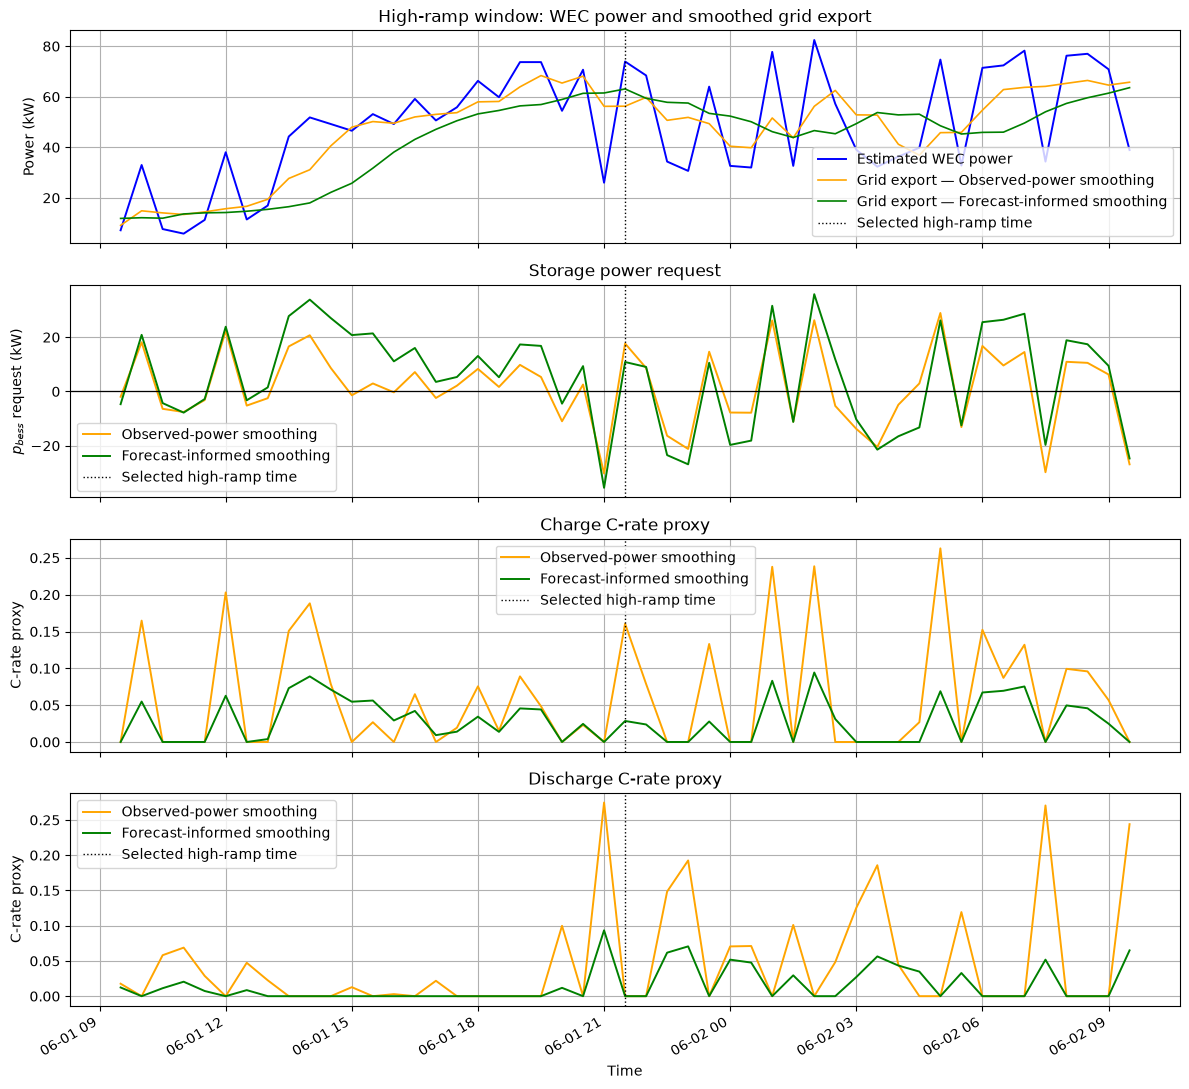

Saved high-ramp duty-cycle outputs:

* `../outputs/tables/notebook_06/high_ramp_window_metadata.csv`
* `../outputs/figures/notebook_06/high_ramp_duty_cycle_window.png`

In [10]:
HIGH_RAMP_CONTEXT_HOURS = 12
HIGH_RAMP_CONTEXT_STEPS = int(HIGH_RAMP_CONTEXT_HOURS / TIME_STEP_HOURS)

high_ramp_candidates = (
    selected_timeseries
    .drop_duplicates(subset=["fold_id", "segment_id", "target_time"])
    .sort_values(["fold_id", "segment_id", "target_time"])
    .copy()
)

high_ramp_candidates = high_ramp_candidates[
    high_ramp_candidates["abs_raw_ramp_kw_per_step"].notna()
].copy()

high_ramp_candidates["position_in_segment"] = (
    high_ramp_candidates
    .groupby(["fold_id", "segment_id"])
    .cumcount()
)

high_ramp_candidates["segment_length"] = (
    high_ramp_candidates
    .groupby(["fold_id", "segment_id"])["target_time"]
    .transform("size")
)

high_ramp_candidates["steps_after"] = (
    high_ramp_candidates["segment_length"]
    - high_ramp_candidates["position_in_segment"]
    - 1
)

high_ramp_candidates = high_ramp_candidates[
    (high_ramp_candidates["position_in_segment"] >= HIGH_RAMP_CONTEXT_STEPS)
    & (high_ramp_candidates["steps_after"] >= HIGH_RAMP_CONTEXT_STEPS)
].copy()

if high_ramp_candidates.empty:
    raise ValueError(
        "No high-ramp candidate has enough context before and after the ramp."
    )

high_ramp_row = high_ramp_candidates.loc[
    high_ramp_candidates["abs_raw_ramp_kw_per_step"].idxmax()
]

high_ramp_fold_id = high_ramp_row["fold_id"]
high_ramp_segment_id = high_ramp_row["segment_id"]
high_ramp_time = high_ramp_row["target_time"]

high_ramp_start = high_ramp_time - pd.Timedelta(hours=HIGH_RAMP_CONTEXT_HOURS)
high_ramp_end = high_ramp_time + pd.Timedelta(hours=HIGH_RAMP_CONTEXT_HOURS)

high_ramp_window = all_replay_profiles[
    (all_replay_profiles["fold_id"] == high_ramp_fold_id)
    & (all_replay_profiles["segment_id"] == high_ramp_segment_id)
    & (all_replay_profiles["target_time"] >= high_ramp_start)
    & (all_replay_profiles["target_time"] <= high_ramp_end)
].copy()

high_ramp_window = high_ramp_window.sort_values(
    ["scenario", "target_time"]
).reset_index(drop=True)


high_ramp_metadata = pd.DataFrame(
    [
        {
            "fold_id": high_ramp_fold_id,
            "segment_id": high_ramp_segment_id,
            "ramp_time": high_ramp_time,
            "raw_ramp_kw_per_step": high_ramp_row["raw_ramp_kw_per_step"],
            "abs_raw_ramp_kw_per_step": high_ramp_row["abs_raw_ramp_kw_per_step"],
            "context_hours_before_after": HIGH_RAMP_CONTEXT_HOURS,
            "window_start": high_ramp_start,
            "window_end": high_ramp_end,
        }
    ]
)

high_ramp_metadata_path = TABLES_DIR / "high_ramp_window_metadata.csv"
high_ramp_metadata.to_csv(high_ramp_metadata_path, index=False)

high_ramp_display = high_ramp_metadata[
    [
        "fold_id",
        "segment_id",
        "ramp_time",
        "abs_raw_ramp_kw_per_step",
        "context_hours_before_after",
    ]
].copy()

high_ramp_display["ramp_time"] = (
    pd.to_datetime(high_ramp_display["ramp_time"])
    .dt.strftime("%Y-%m-%d %H:%M")
)

numeric_cols = high_ramp_display.select_dtypes(include="number").columns
high_ramp_display[numeric_cols] = high_ramp_display[numeric_cols].round(3)

high_ramp_display.columns = (
    high_ramp_display.columns
    .str.replace("_", " ", regex=False)
)

high_ramp_display = high_ramp_display.rename(
    columns={
        "fold id": "fold",
        "segment id": "segment",
        "ramp time": "time",
        "abs raw ramp kw per step": "\\|raw ramp\\| kW / 30 min",
        "context hours before after": "± hours shown",
    }
)

display(Markdown(high_ramp_display.to_markdown(index=False)))


high_ramp_figure_path = (
    FIGURES_DIR
    / "high_ramp_duty_cycle_window.png"
)

fig, axes = plt.subplots(4, 1, figsize=(12, 11), sharex=True)

wec_reference = (
    high_ramp_window
    .drop_duplicates(subset=["target_time"])
    .sort_values("target_time")
)

axes[0].plot(
    wec_reference["target_time"],
    wec_reference["p_wec_kw"],
    color="blue",
    linewidth=1.4,
    label="Estimated WEC power",
)

for scenario, scenario_df in high_ramp_window.groupby("scenario", observed=True):
    scenario_df = scenario_df.sort_values("target_time")
    scenario_name = scenario_df["scenario_name"].iloc[0]
    color = SCENARIO_COLOR_MAP[scenario]

    axes[0].plot(
        scenario_df["target_time"],
        scenario_df["p_grid_kw"],
        color=color,
        linewidth=1.2,
        label=f"Grid export — {scenario_name}",
    )

    axes[1].plot(
        scenario_df["target_time"],
        scenario_df["p_bess_request_kw"],
        color=color,
        linewidth=1.4,
        label=scenario_name,
    )

    axes[2].plot(
        scenario_df["target_time"],
        scenario_df["charge_c_rate_proxy"],
        color=color,
        linewidth=1.4,
        label=scenario_name,
    )

    axes[3].plot(
        scenario_df["target_time"],
        scenario_df["discharge_c_rate_proxy"],
        color=color,
        linewidth=1.4,
        label=scenario_name,
    )

for ax in axes:
    ax.axvline(
        high_ramp_time,
        color="black",
        linewidth=1.0,
        linestyle=":",
        label="Selected high-ramp time",
    )

axes[0].set_title("High-ramp window: WEC power and smoothed grid export")
axes[0].set_ylabel("Power (kW)")
axes[0].legend(loc="best")

axes[1].axhline(0, color="black", linewidth=0.9)
axes[1].set_title("Storage power request")
axes[1].set_ylabel("$p_{bess}$ request (kW)")
axes[1].legend(loc="best")

axes[2].set_title("Charge C-rate proxy")
axes[2].set_ylabel("C-rate proxy")
axes[2].legend(loc="best")

axes[3].set_title("Discharge C-rate proxy")
axes[3].set_ylabel("C-rate proxy")
axes[3].set_xlabel("Time")
axes[3].legend(loc="best")

for ax in axes:
    plt.setp(ax.get_xticklabels(), rotation=30, ha="right")

plt.tight_layout()

fig.savefig(
    high_ramp_figure_path,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

display(
    Markdown(
        "Saved high-ramp duty-cycle outputs:\n\n"
        f"* `{high_ramp_metadata_path}`\n"
        f"* `{high_ramp_figure_path}`"
    )
)

The selected high-ramp window illustrates how a short period of strong WEC-power variation is translated into battery duty-cycle requirements under the two smoothing strategies. In both cases, the storage system absorbs or delivers power to buffer the mismatch between estimated WEC power and the smoothed grid-export target.

The forecast-informed smoothing case appears somewhat smoother in the charge and discharge C-rate proxy panels, with fewer abrupt high spikes than the observed-power smoothing case. In this notebook, that behaviour should be interpreted together with the larger assumed nominal battery capacity for the forecast-informed case. A given power-balancing request therefore translates into a lower normalized C-rate proxy, which makes the response look less abrupt on a power-to-energy basis.

By contrast, the observed-power smoothing case shows sharper C-rate spikes even when the underlying storage-power request is not always larger in absolute terms. This reflects the smaller assumed battery capacity and helps illustrate why rapid ramp buffering can be demanding from a battery-stress perspective.

This high-ramp example does not show a battery failure case, since the requested power was still met under the current sizing assumptions. Instead, it highlights the type of short-duration duty cycle that can motivate future hybrid-storage extensions, such as combining batteries with supercapacitors for fast ramp support.

## 11. Summary and limitations

This optional notebook demonstrated how selected storage-smoothing profiles from [Notebook 05](../outputs/pdf/05_storage_smoothing_metrics.pdf) can be prepared and replayed through a simple SimSES battery workflow.

The replay focused on two 30 min horizon, 2 h smoothing-window cases:

* observed-power smoothing;
* forecast-informed smoothing.

The selected storage profiles were treated as net battery-side power requests. Under the simple scenario-specific BESS configurations used here, the requested battery power was met across the representative replay and across the independently replayed fold/segment profiles. The resulting SOC trajectories, throughput, equivalent full cycles, C-rate proxies, illustrative thermal response, and SimSES state-of-health outputs provide a compact view of battery-operation and degradation-relevant indicators under WEC smoothing duty cycles.

The representative segment showed that the two smoothing strategies can use the battery differently. The forecast-informed case moved more energy in absolute terms over the selected segment, while the observed-power case produced higher normalized C-rate spikes because it was paired with a smaller assumed battery capacity. The cross-segment screening results reinforced this distinction: throughput, equivalent cycling, SOC range, C-rate proxies, and capacity-loss indicators should be interpreted together rather than as isolated metrics.

The high-ramp illustration showed why rapid WEC-power variations remain important even when the current BESS configurations can track the requested power. Short-duration ramping events can create sharper power-to-energy stress on the storage system, especially when normalized by battery size. This motivates future hybrid-storage extensions, such as adding supercapacitor buffering for fast ramps, but no HESS model was introduced in this notebook.

The main limitations are:

* the WEC power signal is a simplified 250 kW proxy, not measured electrical output from a specific WEC device;
* the smoothing profiles are implied storage duty cycles, not optimized BESS dispatch schedules;
* the BESS sizes are transparent replay assumptions derived from Notebook 05 metrics, not techno-economic designs;
* the electrical conversion chain between WEC generator, DC link, BESS, inverter, and grid is not explicitly modelled;
* the thermal response is a simple lumped post-processing model, not a validated cooling or thermal-management simulation;
* the SimSES results depend on the selected Sony LFP cell model and series-parallel scaling assumptions;
* the replay windows are short and should not be interpreted as annual or lifetime degradation predictions;
* the state-of-health outputs are degradation-relevant indicators for comparison, not validated aging estimates.

Overall, this notebook should be read as a reproducible bridge from storage-smoothing metrics to battery-simulation workflow. It shows how the earlier forecasting and smoothing outputs can be carried into BESS operation and degradation-relevant screening, while keeping the assumptions and limitations explicit.